In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

df = pd.read_csv('amazon_sales_data_2025.csv')
df

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending
...,...,...,...,...,...,...,...,...,...,...,...
245,ORD0246,17-03-25,T-Shirt,Clothing,20,2,40,Daniel Harris,Miami,Debit Card,Cancelled
246,ORD0247,30-03-25,Jeans,Clothing,40,1,40,Sophia Miller,Dallas,Debit Card,Cancelled
247,ORD0248,05-03-25,T-Shirt,Clothing,20,2,40,Chris White,Denver,Debit Card,Cancelled
248,ORD0249,08-03-25,Smartwatch,Electronics,150,3,450,Emily Johnson,New York,Debit Card,Cancelled


In [4]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 13.7+ KB


,Price,Quantity,Total Sales
count,250.000000,250.000000,250.000000
mean,343.580000,2.856000,975.380000
std,380.635808,1.429489,1252.112254
min,15.000000,1.000000,15.000000
25%,40.000000,2.000000,100.000000
50%,150.000000,3.000000,400.000000
75%,600.000000,4.000000,1500.000000
max,1200.000000,5.000000,6000.000000


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,250.0,343.580,380.635808,15.0,40.0,150.0,600.0,1200.0
Quantity,250.0,2.856,1.429489,1.0,2.0,3.0,4.0,5.0
Total Sales,250.0,975.380,1252.112254,15.0,100.0,400.0,1500.0,6000.0


In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print(df.columns)

Index(['order_id', 'date', 'product', 'category', 'price', 'quantity',
       'total_sales', 'customer_name', 'customer_location', 'payment_method',
       'status'],
      dtype='object')


In [14]:
df.isnull().sum()

order_id             0
date                 0
product              0
category             0
price                0
quantity             0
total_sales          0
customer_name        0
customer_location    0
payment_method       0
status               0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

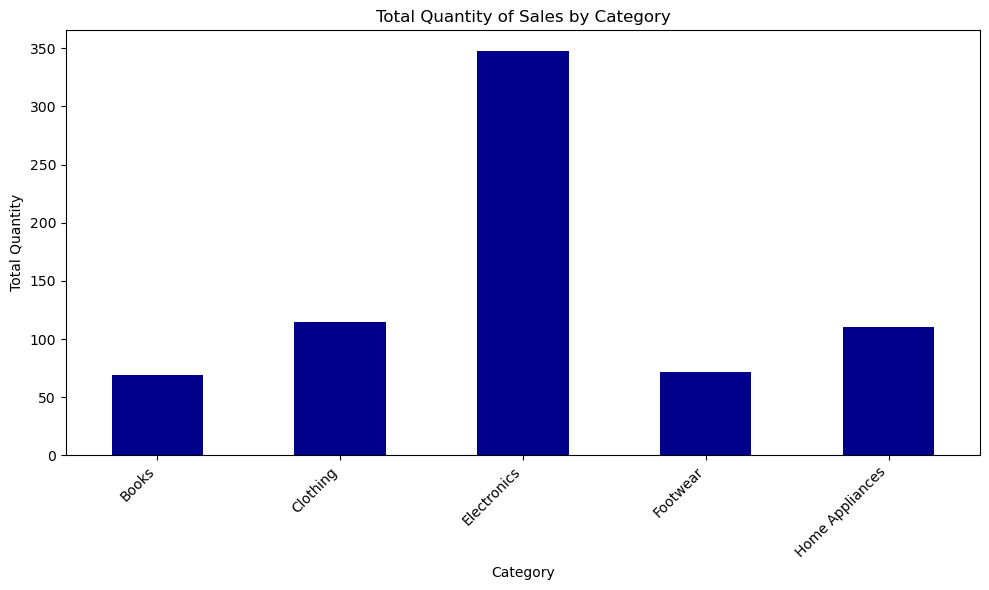

In [25]:
# Total Quantity of sales by category
sum_cat = df.groupby('category')['quantity'].sum()
plt.figure(figsize=(10,6))
sum_cat.plot(kind='bar', color='Darkblue')
plt.title("Total Quantity of Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

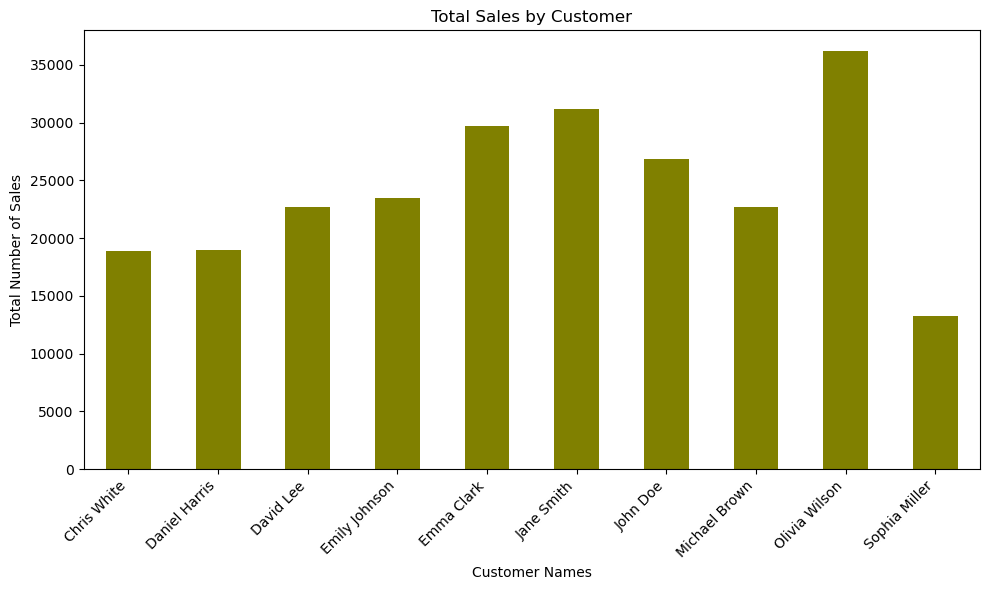

In [37]:
# Total Sales by Customer
cust_sale = df.groupby('customer_name')['total_sales'].sum()
plt.figure(figsize=(10,6))
cust_sale.plot(kind='bar', color='olive')
plt.title("Total Sales by Customer")
plt.xlabel("Customer Names")
plt.ylabel("Total Number of Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

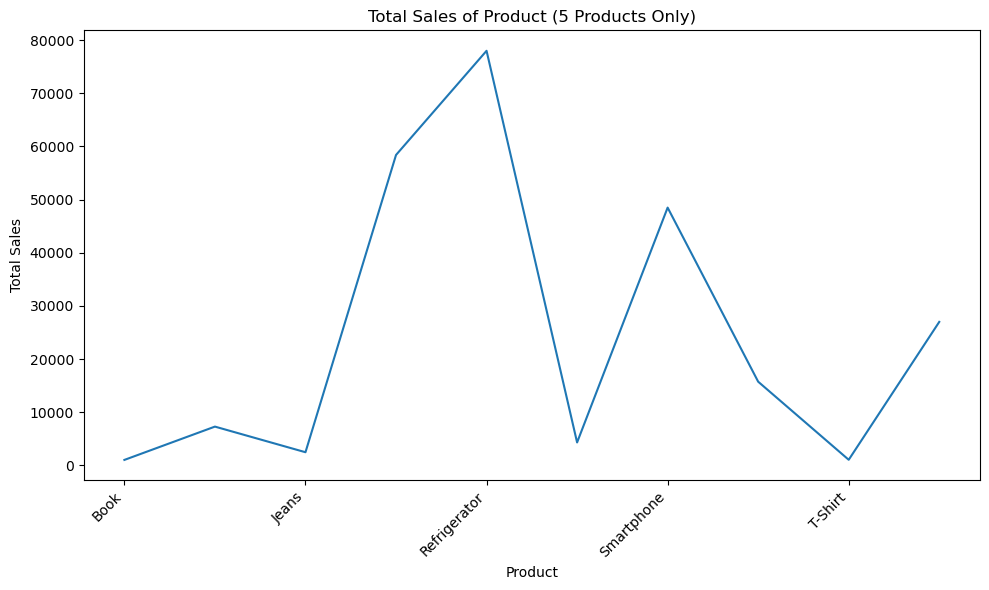

In [39]:
# Total sales of Product (only 5)
total_sales = df.groupby('product')['total_sales'].sum()
plt.figure(figsize=(10,6))
total_sales.plot()
plt.title("Total Sales of Product (5 Products Only)")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()